<a href="https://colab.research.google.com/github/Optimus0205/Computer-Vision/blob/main/10_InceptionNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## GoogLeNet Architecture


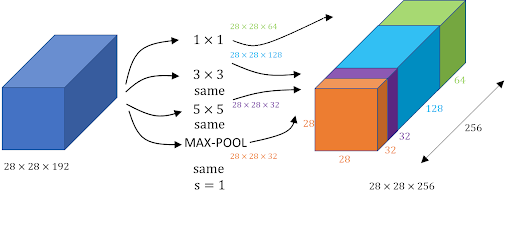

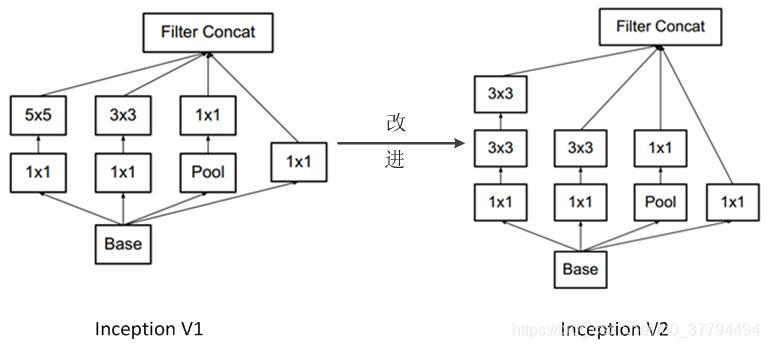




## Version 3
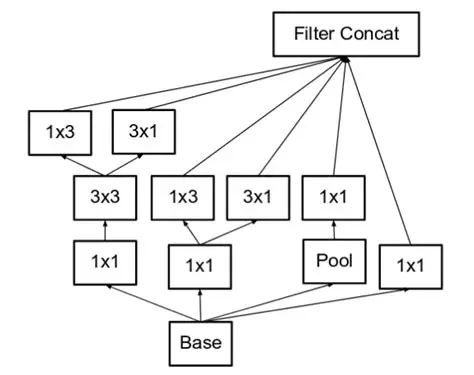

## Importing the dataset

In [1]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_5aff8763a11c2fb1654d67dea213a0df"

In [2]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [3]:
!kaggle datasets download -d samuelcortinhas/sports-balls-multiclass-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/sports-balls-multiclass-image-classification
License(s): CC0-1.0
100% 401M/401M [00:04<00:00, 94.2MB/s]



In [4]:
!unzip /content/sports-balls-multiclass-image-classification.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/cricket_ball/cricket_ball_182.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_183.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_185.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_186.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_187.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_189.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_19.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_190.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_191.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_192.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_195.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_196.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_199.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_200.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_

## Importing Packages

In [5]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.layers import Rescaling

import tensorflow as tf
import os

# For reproducibility
import numpy as np
import random
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

seed=123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Inception Module as defined in the paper
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce, filters_5x5, filters_pool_proj):
    # 1x1 Convolution
    conv_1x1=layers.Conv2D(filters_1x1,(1,1),padding='same', activation='relu')(x)

    # 3x3 Convolution
    conv_3x3=layers.Conv2D(filters_3x3_reduce,(1,1),padding='same', activation='relu')(x)
    conv_3x3=layers.Conv2D(filters_3x3,(3,3),padding='same', activation='relu')(conv_3x3)

    # 5x5 Convolution
    conv_5x5=layers.Conv2D(filters_5x5_reduce,(1,1),padding='same', activation='relu')(x)
    conv_5x5=layers.Conv2D(filters_5x5,(5,5),padding='same', activation='relu')(conv_5x5)

    # MaxPooling followed by 1x1 convolution
    pool_proj=layers.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    pool_proj=layers.Conv2D(filters_pool_proj, (1,1), strides=(1,1), padding='same', activation='relu')(pool_proj)

    # Concatenate filters from all branches
    output=layers.concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=-1)
    return output

In [8]:
# Auxiliary classifier for training(deep supervision)
def auxiliary_classifier(x, num_classes):
    aux=layers.AveragePooling2D((5,5), strides=(3,3))(x)
    aux=layers.Conv2D(128,(1,1), padding='same', activation='relu')(aux)
    aux=layers.Flatten()(aux)
    aux=layers.Dense(1024,activation='relu')(aux)
    aux=layers.Dropout(0.7)(aux)
    aux=layers.Dense(num_classes, activation='softmax')(aux)
    return aux